In [20]:

# cpu cores for sampling
#os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=4'

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import pandas as pd

import jax.numpy as jnp
from jax import random

import numpyro
import numpyro.distributions as dist


from numpyro.infer import MCMC, NUTS
import pickle


import seaborn as sns


# Data

In [14]:
# stage height data

#Downstream
bawden_stageheight_all = pd.read_csv('./../data/orara/stageheight_bawden.csv',skiprows=9)
bawden_stageheight_all['Date'] = pd.to_datetime(bawden_stageheight_all['#Timestamp'])

#Upstream
glenreagh_stageheight_all = pd.read_csv('./../data/orara/stageheight_glenreagh.csv',skiprows=9)
glenreagh_stageheight_all['Date'] = pd.to_datetime(glenreagh_stageheight_all['#Timestamp'])

# rain data

nanaglen_rain = pd.read_csv('./../data/orara/nana_glen.csv')
nanaglen_rain['dateInt']=nanaglen_rain['Year'].astype(str) + nanaglen_rain['Month'].astype(str).str.zfill(2)+ nanaglen_rain['Day'].astype(str).str.zfill(2)

nanaglen_rain['Date'] = pd.to_datetime(nanaglen_rain['dateInt'],format='%Y%m%d')

# time period decission

y_l = 2008
y_h = 2010

#slicing

dates_train = glenreagh_stageheight_all['Date'][(glenreagh_stageheight_all['Date'].dt.year>=y_l)&(glenreagh_stageheight_all['Date'].dt.year<=y_h)].dt.date
dates_test = glenreagh_stageheight_all['Date'][(glenreagh_stageheight_all['Date'].dt.year>=y_h+1)&(glenreagh_stageheight_all['Date'].dt.year<=y_h+1)].dt.date

hu_train = glenreagh_stageheight_all['Value'][(glenreagh_stageheight_all['Date'].dt.year>=y_l)&(glenreagh_stageheight_all['Date'].dt.year<=y_h)].values
r_train = nanaglen_rain['Value'][(nanaglen_rain['Date'].dt.year>=y_l)&(nanaglen_rain['Date'].dt.year<=y_h)].values
hd_train = bawden_stageheight_all['Value'][(bawden_stageheight_all['Date'].dt.year>=y_l)&(bawden_stageheight_all['Date'].dt.year<=y_h)].values

hu_test = glenreagh_stageheight_all['Value'][(glenreagh_stageheight_all['Date'].dt.year>=y_h+1)&(glenreagh_stageheight_all['Date'].dt.year<=y_h+1)].values
r_test = nanaglen_rain['Value'][(nanaglen_rain['Date'].dt.year>=y_h+1)&(nanaglen_rain['Date'].dt.year<=y_h+1)].values
hd_test = bawden_stageheight_all['Value'][(bawden_stageheight_all['Date'].dt.year>=y_h+1)&(bawden_stageheight_all['Date'].dt.year<=y_h+1)].values

ticklabels_train = dates_train.astype(str).values
ticklabels_test = dates_test.astype(str).values

def min_max_norm(x):
    return (x-x.min())/(x.max()-x.min())

In [15]:
# training data

hu = hu_train[:-1]
r = r_train[:-1]

hd = hd_train[1:]


hu = jnp.delete(hu,np.argwhere(np.isnan(r))[:,0])
hd = jnp.delete(hd,np.argwhere(np.isnan(r))[:,0])
r = jnp.delete(r,np.argwhere(np.isnan(r))[:,0])


x = jnp.vstack((jnp.array([1 for x in range(len(hu))]),min_max_norm(np.log(hu)), min_max_norm(r), min_max_norm(jnp.log(hu)*r)))

# Helper functions

In [3]:
def nan_dates(df,c):
    return np.where(np.isnan(df),c,np.nan),np.where(~np.isnan(df),c,np.nan)

def zero_dates(df,c):
    return np.where(df==0,c,np.nan),np.where(df!=0,c,np.nan)

def nan_plot(df,ticks,c,i):
    nans,no_nans = nan_dates(df,c)
    plt.figure(figsize=(15,5))
    tot = len(nans) + len(no_nans)
    plt.scatter([x for x in range(len(no_nans))],no_nans,c='green')
    plt.scatter([x for x in range(len(nans))],nans,c='red',s=50)
    plt.xticks(ticks=[x for x in range(0,len(nans),i)],labels=[ticks[x] for x in range(0,len(nans),i)],rotation=90)
    plt.show()

def zero_plots(df,ticks,c,i):
    nans,no_nans = zero_dates(df,c)
    plt.figure(figsize=(15,5))
    tot = len(nans) + len(no_nans)
    plt.scatter([x for x in range(len(no_nans))],no_nans,c='green')
    plt.scatter([x for x in range(len(nans))],nans,c='red',s=50)
    plt.xticks(ticks=[x for x in range(0,len(nans),i)],labels=[ticks[x] for x in range(0,len(nans),i)],rotation=90)
    plt.show()

# Models

In [16]:
def single_model_m1(x,hd=None):
    n = x.shape[1]
    p = x.shape[0]
    beta = numpyro.sample('beta',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))
    phi = numpyro.sample('phi',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))

    
    sig_mu = numpyro.sample('sigma_mu',dist.InverseGamma(1,2))
    sig_sig = numpyro.sample('sigma_sig',dist.InverseGamma(1,2))
    
    e_mu = dist.Normal(0,sig_mu).sample(rng_key_,sample_shape=(1,n))
    e_sig = dist.Normal(0,sig_sig).sample(rng_key_,sample_shape=(1,n))

    mean = numpyro.deterministic('mean',jnp.exp(x.T @ beta + e_mu))
    sd = numpyro.deterministic('sd', jnp.exp(x.T @ phi + e_sig ))
    

    numpyro.sample("obs", dist.Gamma(mean**2/sd**2 ,rate=mean/sd**2), obs=hd)

def mixture_model_m2(x,hd=None):
    n = x.shape[1]
    p = x.shape[0]
    
    beta1 = numpyro.sample('beta1',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))
    phi1 = numpyro.sample('phi1',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))

    beta2 = numpyro.sample('beta2',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))
    phi2 = numpyro.sample('phi2',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))

    omega = numpyro.sample('omega',dist.MultivariateNormal(jnp.zeros(p),covariance_matrix = n*jnp.eye(p)))

    sig_mu1 = numpyro.sample('sig_mu1', dist.InverseGamma(1,2))
    sig_mu2 = numpyro.sample('sig_mu2', dist.InverseGamma(1,2))

    sig_sig1 = numpyro.sample('sig_sig1', dist.InverseGamma(1,2))
    sig_sig2 = numpyro.sample('sig_sig2', dist.InverseGamma(1,2))

    e_mu1 = dist.Normal(0,sig_mu1).sample(rng_key_,sample_shape=(1,x.shape[1]))
    e_mu2 = dist.Normal(0,sig_mu2).sample(rng_key_,sample_shape=(1,x.shape[1]))

    e_sig1 = dist.Normal(0,sig_sig1).sample(rng_key_,sample_shape=(1,x.shape[1]))
    e_sig2 = dist.Normal(0,sig_sig2).sample(rng_key_,sample_shape=(1,x.shape[1]))


    mean1 = numpyro.deterministic('mean1',jnp.exp(x.T @ beta1 + e_mu1))
    sd1 = numpyro.deterministic('sd1', jnp.exp(x.T @ phi1 + e_sig1))

    mean2 = numpyro.deterministic('mean2',jnp.exp(x.T @ beta2 + e_mu2))
    sd2 = numpyro.deterministic('sd2', jnp.exp(x.T @ phi2 + e_sig2))

    comp1 = dist.Gamma(mean1**2/sd1**2, rate=mean1/sd1**2)
    comp2 = dist.Gamma(mean2**2/sd2**2, rate=mean2/sd2**2)

    w_exp = jnp.exp(x.T @ omega)
    w_1 = w_exp / (1 + w_exp)
    gate = numpyro.deterministic('gate',jnp.stack((w_1, 1- w_1), axis = -1))
    mixture = dist.MixtureGeneral(dist.Categorical(probs=gate), [comp1,comp2])

    numpyro.sample('obs', mixture, obs=hd)

# True data from a single model (M1)

In [7]:
# Fix params for the single model

beta = jnp.array([-0.81,3.85,0.71, -1.29])
phi = jnp.array([-2.54,5.13,7.29,-9.0])

sig_mu = 0.04
sig_sig = 0.11

n = x.shape[1]

# Generate 1000 realizations from the set parameter values for a single model

h_sim = np.empty(len(hd))

for i in range(1000):
    seed = np.random.seed(seed=i)
    noise_mu = st.norm(0,sig_mu).rvs(size=n, random_state = i)
    noise_sig = st.norm(0,sig_sig).rvs(size=n, random_state = i)

    # Generate the mus and sigs

    mu = jnp.exp(x.T @ beta + noise_mu)
    std = jnp.exp(x.T @ phi + noise_sig)

    # Generate Gams

    gam = st.gamma(mu**2/std**2,scale=std**2/mu)

    sim = gam.rvs(random_state = i)
    h_sim = np.vstack((h_sim,sim))

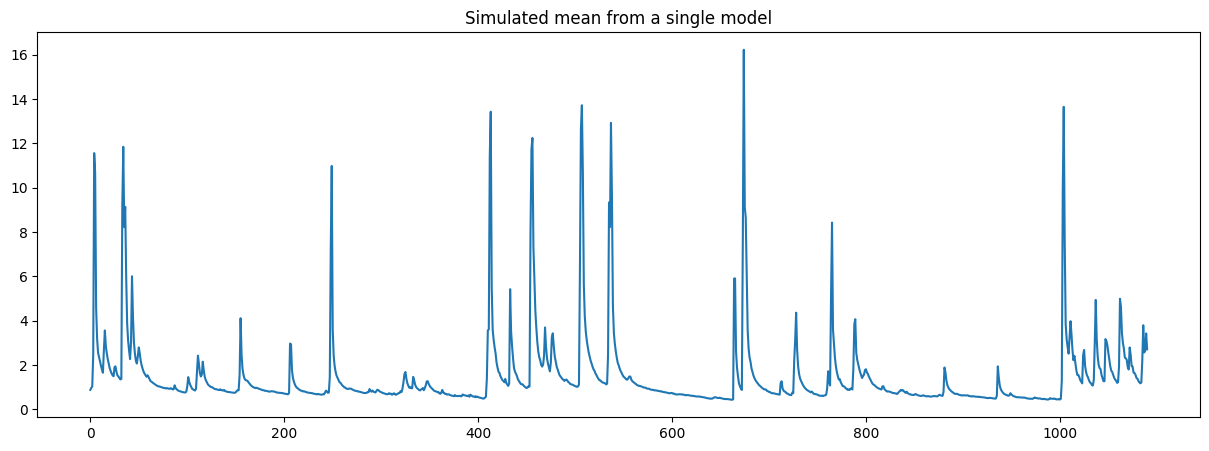

In [8]:
h_sim_mean = np.mean(h_sim[1:,:],axis=0)

plt.figure(figsize=(15,5))
plt.plot(h_sim_mean)
plt.title('Simulated mean from a single model')
plt.show()

## Estimate using a single model (M1) - 50 runs

In [ ]:
# run the mcmc in a loop
beta_post = []
phi_post = []
sig_mu_post = []
sig_sig_post = []

for i in range(1,51):
    rng_key_ = random.PRNGKey(321)
    n_samples = 2000
    n_warmup = 2000
    # build kernel and run NUTS
    kernel = NUTS(single_model_m1, max_tree_depth=5)#, jit_compile=True, ignore_jit_warnings=True)
    mcmc_s = MCMC(
        kernel,
        num_warmup=n_warmup,
        num_samples=n_samples,
        num_chains=1,
    )
    mcmc_s.run(rng_key_,x,hd=h_sim[i,:])
    trace_s = mcmc_s.get_samples()
    beta_post.append(np.mean(trace_s['beta'],axis=0))
    phi_post.append(np.mean(trace_s['phi'],axis=0))
    sig_mu_post.append(np.mean(trace_s['sigma_mu']))
    sig_sig_post.append(np.mean(trace_s['sigma_sig']))

In [55]:
beta_arr = np.array(beta_post)
phi_arr = np.array(phi_post)
sig_mu_arr = np.array(sig_mu_post)
sig_sig_arr = np.array(sig_sig_post)

In [68]:
single_model_dict = {'beta':beta_arr, 'phi':phi_arr,
                     'sig_mu': sig_mu_arr, 'sig_sig':sig_sig_arr }

In [72]:
with open('./../results/simulation/bawden_sim_single', 'wb') as fp:
    pickle.dump(single_model_dict, fp)
    print('single model simulation samples saved successfully to file')

single model simulation samples saved successfully to file


## Estimate using a mixture model (M2) - 50 runs

In [ ]:
# run the mcmc in a loop for the mixture
beta1_post = []
phi1_post = []
sig_mu1_post = []
sig_sig1_post = []
beta2_post = []
phi2_post = []
sig_mu2_post = []
sig_sig2_post = []
omega_post = []

for i in range(1,51):
    rng_key_ = random.PRNGKey(119)
    n_samples = 8000
    n_warmup = 2000
    # build kernel and run NUTS
    kernel = NUTS(mixture_model_m2, max_tree_depth=5)#, jit_compile=True, ignore_jit_warnings=True)
    mcmc_m = MCMC(
        kernel,
        num_warmup=n_warmup,
        num_samples=n_samples,
        num_chains=1,
    )
    mcmc_m.run(rng_key_,x,hd=h_sim[i,:])
    trace_m = mcmc_m.get_samples()
    beta1_post.append(np.mean(trace_m['beta1'],axis=0))
    phi1_post.append(np.mean(trace_m['phi1'],axis=0))
    sig_mu1_post.append(np.mean(trace_m['sig_mu1']))
    sig_sig1_post.append(np.mean(trace_m['sig_sig1']))

    beta2_post.append(np.mean(trace_m['beta2'],axis=0))
    phi2_post.append(np.mean(trace_m['phi2'],axis=0))
    sig_mu2_post.append(np.mean(trace_m['sig_mu2']))
    sig_sig2_post.append(np.mean(trace_m['sig_sig2']))

    omega_post.append(np.mean(trace_m['omega'], axis=0))

In [103]:
beta1_arr = np.array(beta1_post)
phi1_arr = np.array(phi1_post)
sig_mu1_arr = np.array(sig_mu1_post)
sig_sig1_arr = np.array(sig_sig1_post)

beta2_arr = np.array(beta2_post)
phi2_arr = np.array(phi2_post)
sig_mu2_arr = np.array(sig_mu2_post)
sig_sig2_arr = np.array(sig_sig2_post)

omega_arr = np.array(omega_post)

In [104]:
mixture_model_dict = {'beta1':beta1_arr, 'phi1':phi1_arr,
                     'sig_mu1': sig_mu1_arr, 'sig_sig1':sig_sig1_arr,
                      'beta2':beta2_arr, 'phi2':phi2_arr,
                     'sig_mu2': sig_mu2_arr, 'sig_sig2':sig_sig2_arr,
                     'omega':omega_arr}

In [105]:
with open('./../results/simulation/bawden_sim_mixture', 'wb') as fp:
    pickle.dump(mixture_model_dict, fp)
    print('mixture model simulation samples saved successfully to file')

mixture model simulation samples saved successfully to file


# True data from a mixture model (M2)

In [19]:
# Fix parameter values 

beta1 = jnp.array([-0.8,3.65,-0.28, -1.57])
phi1 = jnp.array([-3.26,3.64,6.44,15.05])

beta2 = jnp.array([-0.03,3.02,-2.87, 2.24])
phi2 = jnp.array([-0.59,2.14,0.57,-0.32])

sig_mu1 = 0.04
sig_sig1 = 0.12

sig_mu2 = 0.17
sig_sig2 = 0.37

omega = jnp.array([6.47,-11.84,-22.35, 5.56])

In [ ]:
h_sim_mix = np.empty(len(hd))

for i in range(1000):
    seed = np.random.seed(seed=i)
    noise_mu1 = st.norm(0,sig_mu1).rvs(size=n, random_state = i)
    noise_sig1 = st.norm(0,sig_sig1).rvs(size=n, random_state = i)

    noise_mu2 = st.norm(0,sig_mu2).rvs(size=n, random_state = i)
    noise_sig2 = st.norm(0,sig_sig2).rvs(size=n, random_state = i)

    # Generate the mus and sigs

    mu1 = jnp.exp(x.T @ beta1 + noise_mu1)
    std1 = jnp.exp(x.T @ phi1 + noise_sig1)

    mu2 = jnp.exp(x.T @ beta2 + noise_mu2)
    std2 = jnp.exp(x.T @ phi2 + noise_sig2)

    # Generate Gams

    gam1 = st.gamma(mu1**2/std1**2,scale=std1**2/mu1)
    gam2 = st.gamma(mu2**2/std2**2,scale=std2**2/mu2)  

    #mixture weight assignment
    w_exp = jnp.exp(x.T @ omega)
    w_1 = w_exp / (1 + w_exp)
    gate = numpyro.deterministic('gate',jnp.stack((w_1, 1- w_1), axis = -1))

    #Generate the latent variable for the model selection
    bern = st.bernoulli(gate[:,0])

    sim = bern.rvs(random_state = i)*gam1.rvs(random_state = i) + (1-bern.rvs(random_state = i))*gam2.rvs(random_state = i)
    h_sim_mix = np.vstack((h_sim_mix,sim))

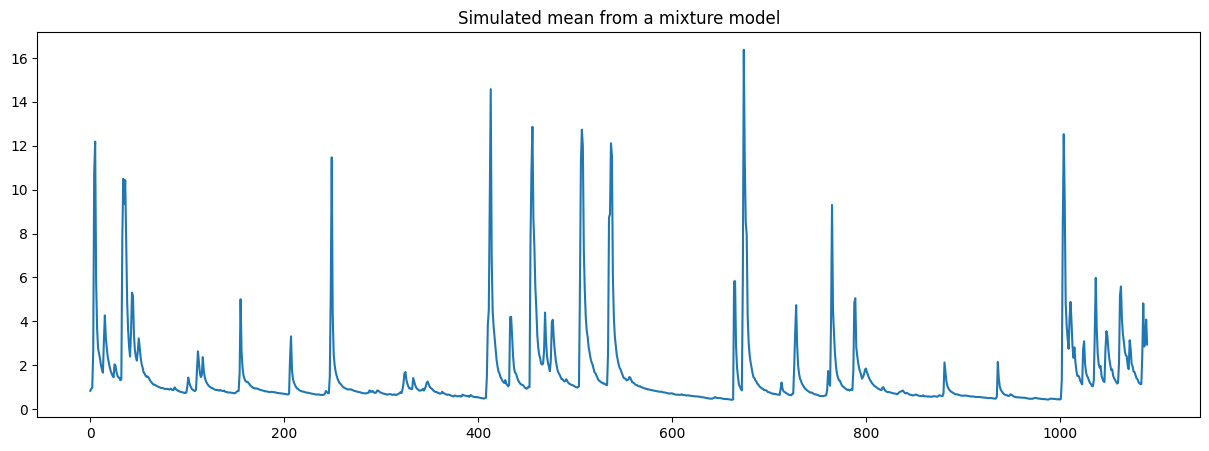

In [94]:
h_sim_mix_mean = np.mean(h_sim_mix[1:,:],axis=0)

plt.figure(figsize=(15,5))
plt.plot(h_sim_mix_mean)
plt.title('Simulated mean from a mixture model')
plt.show()

## Estimate using a single model (M1)

In [ ]:
# run the mcmc in a loop
beta_post = []
phi_post = []
sig_mu_post = []
sig_sig_post = []

for i in range(1,51):
    rng_key_ = random.PRNGKey(321)
    n_samples = 2000
    n_warmup = 2000
    # build kernel and run NUTS
    kernel = NUTS(single_model_m1, max_tree_depth=5)#, jit_compile=True, ignore_jit_warnings=True)
    mcmc_s = MCMC(
        kernel,
        num_warmup=n_warmup,
        num_samples=n_samples,
        num_chains=1,
    )
    mcmc_s.run(rng_key_,x,hd=h_sim_mix[i,:])
    trace_s = mcmc_s.get_samples()
    beta_post.append(np.mean(trace_s['beta'],axis=0))
    phi_post.append(np.mean(trace_s['phi'],axis=0))
    sig_mu_post.append(np.mean(trace_s['sigma_mu']))
    sig_sig_post.append(np.mean(trace_s['sigma_sig']))

In [60]:
beta_arr = np.array(beta_post)
phi_arr = np.array(phi_post)
sig_mu_arr = np.array(sig_mu_post)
sig_sig_arr = np.array(sig_sig_post)

In [61]:
mix_sim_single_model_dict = {'beta':beta_arr, 'phi':phi_arr,
                     'sig_mu': sig_mu_arr, 'sig_sig':sig_sig_arr }

In [62]:
with open('./../results/simulation/mix_sim_bawden_single', 'wb') as fp:
    pickle.dump(mix_sim_single_model_dict, fp)
    print('single model simulation samples saved successfully to file')

single model simulation samples saved successfully to file


## Estimate using a mixture model (M2)

In [ ]:
# run the mcmc in a loop for the mixture
beta1_post = []
phi1_post = []
sig_mu1_post = []
sig_sig1_post = []
beta2_post = []
phi2_post = []
sig_mu2_post = []
sig_sig2_post = []
omega_post = []

for i in range(1,51):
    print('Simulation: ',i)
    rng_key_ = random.PRNGKey(111)
    n_samples = 8000
    n_warmup = 2000
    # build kernel and run NUTS
    kernel = NUTS(mixture_model_m2, max_tree_depth=4)#, jit_compile=True, ignore_jit_warnings=True)
    mcmc_m = MCMC(
        kernel,
        num_warmup=n_warmup,
        num_samples=n_samples,
        num_chains=1,
    )
    mcmc_m.run(rng_key_,x,hd=h_sim_mix[i,:])
    trace_m = mcmc_m.get_samples()
    beta1_post.append(np.mean(trace_m['beta1'],axis=0))
    phi1_post.append(np.mean(trace_m['phi1'],axis=0))
    sig_mu1_post.append(np.mean(trace_m['sig_mu1']))
    sig_sig1_post.append(np.mean(trace_m['sig_sig1']))

    beta2_post.append(np.mean(trace_m['beta2'],axis=0))
    phi2_post.append(np.mean(trace_m['phi2'],axis=0))
    sig_mu2_post.append(np.mean(trace_m['sig_mu2']))
    sig_sig2_post.append(np.mean(trace_m['sig_sig2']))

    omega_post.append(np.mean(trace_m['omega'], axis=0))

In [29]:
beta1_arr = np.array(beta1_post)
phi1_arr = np.array(phi1_post)
sig_mu1_arr = np.array(sig_mu1_post)
sig_sig1_arr = np.array(sig_sig1_post)

beta2_arr = np.array(beta2_post)
phi2_arr = np.array(phi2_post)
sig_mu2_arr = np.array(sig_mu2_post)
sig_sig2_arr = np.array(sig_sig2_post)

omega_arr = np.array(omega_post)

In [30]:
mix_sim_mixture_model_dict = {'beta1':beta1_arr, 'phi1':phi1_arr,
                     'sig_mu1': sig_mu1_arr, 'sig_sig1':sig_sig1_arr,
                      'beta2':beta2_arr, 'phi2':phi2_arr,
                     'sig_mu2': sig_mu2_arr, 'sig_sig2':sig_sig2_arr,
                     'omega':omega_arr}

In [31]:
with open('./../results/simulation/mix_sim_bawden_mixture', 'wb') as fp:
    pickle.dump(mix_sim_mixture_model_dict, fp)
    print('mixture model simulation samples saved successfully to file')

mixture model simulation samples saved successfully to file


# Plots

## Single model generated data

In [14]:
with open('./../results/simulation/bawden_sim_single', 'rb') as fp:
    single_model_single_estimate = pickle.load(fp)

with open('./../results/simulation/bawden_sim_mixture', 'rb') as fp:
    single_model_mixture_estimate = pickle.load(fp)
    

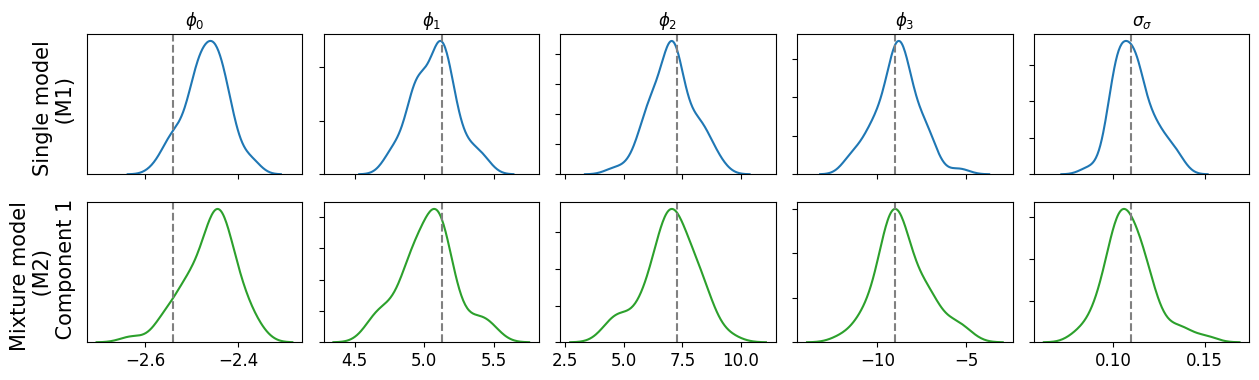

In [33]:
# Plot for  Phi
plt.rcParams['xtick.labelsize'] = 12
fig, axs = plt.subplots(2,5, figsize=(15,4), sharex='col')
#Single model
sns.kdeplot(single_model_single_estimate['phi'][:,0], ax=axs[0,0])
sns.kdeplot(single_model_single_estimate['phi'][:,1],  ax=axs[0,1])
sns.kdeplot(single_model_single_estimate['phi'][:,2],  ax=axs[0,2])
sns.kdeplot(single_model_single_estimate['phi'][:,3], ax=axs[0,3])
sns.kdeplot(single_model_single_estimate['sig_sig'],  ax=axs[0,4])

#Mixture mdoel
sns.kdeplot(single_model_mixture_estimate['phi2'][:,0],  ax=axs[1,0], color='#2ca02c')
sns.kdeplot(single_model_mixture_estimate['phi2'][:,1],  ax=axs[1,1], color='#2ca02c')
sns.kdeplot(single_model_mixture_estimate['phi2'][:,2],  ax=axs[1,2], color='#2ca02c')
sns.kdeplot(single_model_mixture_estimate['phi2'][:,3],  ax=axs[1,3], color='#2ca02c')
sns.kdeplot(single_model_mixture_estimate['sig_sig2'],  ax=axs[1,4], color='#2ca02c')

#Setting true fixed values

axs[0,0].set_title(r'$\phi_0$',fontsize=12)
axs[0,1].set_title(r'$\phi_1$',fontsize=12)
axs[0,2].set_title(r'$\phi_2$',fontsize=12)
axs[0,3].set_title(r'$\phi_3$',fontsize=12)
axs[0,4].set_title(r'$\sigma_{\sigma}$',fontsize=12)

axs[0,0].axvline(x = -2.54, linestyle = "dashed", color='grey')
axs[0,1].axvline(x = 5.13, linestyle = "dashed", color='grey')
axs[0,2].axvline(x = 7.29, linestyle = "dashed", color='grey')
axs[0,3].axvline(x = -9.00, linestyle = "dashed", color='grey')
axs[0,4].axvline(x = 0.11, linestyle = "dashed", color='grey')

axs[1,0].axvline(x = -2.54, linestyle = "dashed", color='grey')
axs[1,1].axvline(x = 5.13, linestyle = "dashed", color='grey')
axs[1,2].axvline(x = 7.29, linestyle = "dashed", color='grey')
axs[1,3].axvline(x = -9.00, linestyle = "dashed", color='grey')
axs[1,4].axvline(x = 0.11, linestyle = "dashed", color='grey')

# Remove the ticklabels for y axis

axs[0,0].set_yticks([])
axs[1,0].set_yticks([])

# Give labels for models
axs[0,0].set_ylabel('Single model \n (M1)',fontsize=15)
axs[1,0].set_ylabel('Mixture model \n (M2) \n Component 1',fontsize=15)


for ax in axs.flat:
    ax.label_outer()

plt.subplots_adjust(wspace=0.1, hspace=0.2)

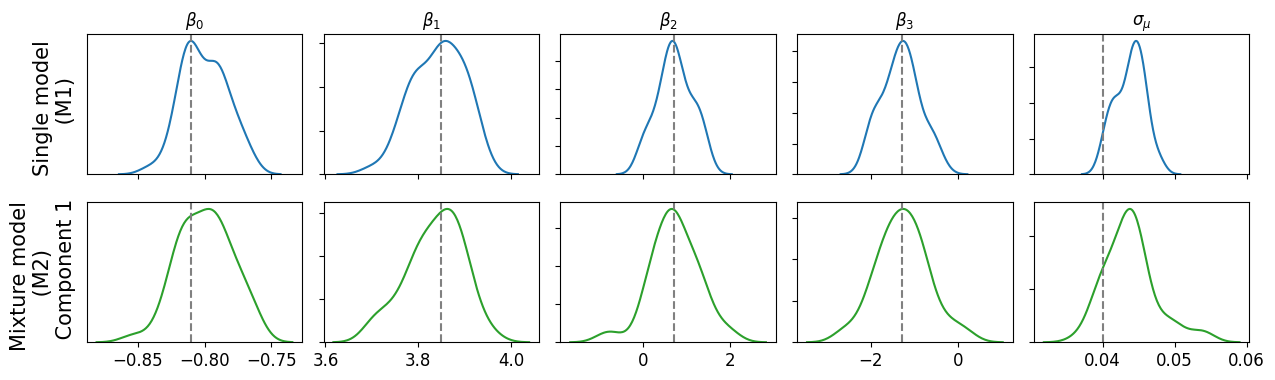

In [64]:
#Plot for Beta

fig, axs = plt.subplots(2,5, figsize=(15,4), sharex='col')
plt.rcParams['xtick.labelsize'] = 12
#Single model
sns.kdeplot(single_model_single_estimate['beta'][:,0], ax=axs[0,0])
sns.kdeplot(single_model_single_estimate['beta'][:,1], ax=axs[0,1])
sns.kdeplot(single_model_single_estimate['beta'][:,2],  ax=axs[0,2])
sns.kdeplot(single_model_single_estimate['beta'][:,3],  ax=axs[0,3])
sns.kdeplot(single_model_single_estimate['sig_mu'],  ax=axs[0,4])

#Mixture mdoel
sns.kdeplot(single_model_mixture_estimate['beta2'][:,0],  ax=axs[1,0], color='#2ca02c')
sns.kdeplot(single_model_mixture_estimate['beta2'][:,1],  ax=axs[1,1], color='#2ca02c')
sns.kdeplot(single_model_mixture_estimate['beta2'][:,2],  ax=axs[1,2], color='#2ca02c')
sns.kdeplot(single_model_mixture_estimate['beta2'][:,3],  ax=axs[1,3], color='#2ca02c')
sns.kdeplot(single_model_mixture_estimate['sig_mu2'],  ax=axs[1,4], color='#2ca02c')

#Setting true fixed values

axs[0,0].set_title(r'$\beta_0$',fontsize=12)
axs[0,1].set_title(r'$\beta_1$',fontsize=12)
axs[0,2].set_title(r'$\beta_2$',fontsize=12)
axs[0,3].set_title(r'$\beta_3$',fontsize=12)
axs[0,4].set_title(r'$\sigma_{\mu}$',fontsize=12)

axs[0,0].axvline(x = -0.81, linestyle = "dashed", color='grey')
axs[0,1].axvline(x = 3.85, linestyle = "dashed", color='grey')
axs[0,2].axvline(x = 0.71, linestyle = "dashed", color='grey')
axs[0,3].axvline(x = -1.29, linestyle = "dashed", color='grey')
axs[0,4].axvline(x = 0.04, linestyle = "dashed", color='grey')

axs[1,0].axvline(x = -0.81, linestyle = "dashed", color='grey')
axs[1,1].axvline(x = 3.85, linestyle = "dashed", color='grey')
axs[1,2].axvline(x = 0.71, linestyle = "dashed", color='grey')
axs[1,3].axvline(x = -1.29, linestyle = "dashed", color='grey')
axs[1,4].axvline(x = 0.04, linestyle = "dashed", color='grey')

# Remove the ticklabels for y axis

axs[0,0].set_yticks([])
axs[1,0].set_yticks([])

# Give labels for models
axs[0,0].set_ylabel('Single model \n (M1)',fontsize=15)
axs[1,0].set_ylabel('Mixture model \n (M2) \n Component 1',fontsize=15)

#axs[0,0].set_xlabel('Single model')
for ax in axs.flat:
    ax.label_outer()

plt.subplots_adjust(wspace=0.1, hspace=0.2)

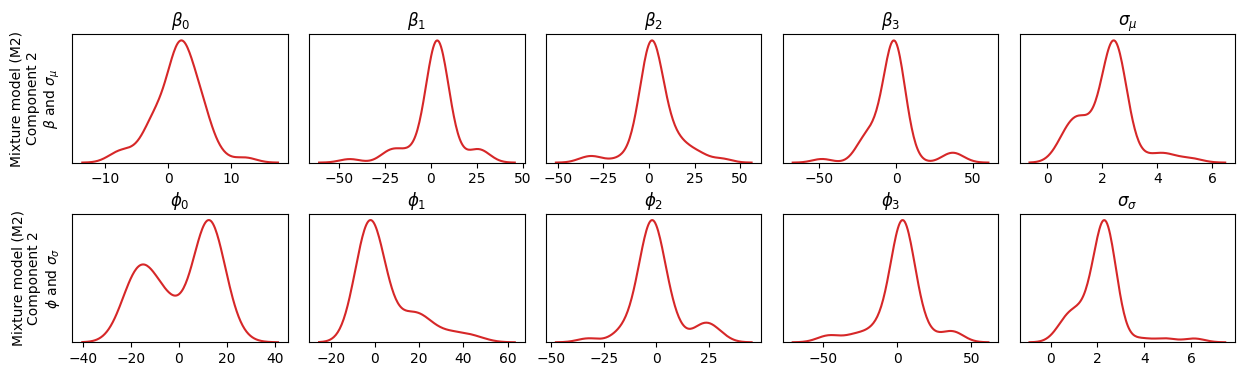

In [83]:
#Plot of the rejected mixture model

fig, axs = plt.subplots(2,5, figsize=(15,4))


#Mixture model rejected Beta
sns.kdeplot(single_model_mixture_estimate['beta1'][:,0],  ax=axs[0,0], color='#d62728')
sns.kdeplot(single_model_mixture_estimate['beta1'][:,1],  ax=axs[0,1], color='#d62728')
sns.kdeplot(single_model_mixture_estimate['beta1'][:,2],  ax=axs[0,2], color='#d62728')
sns.kdeplot(single_model_mixture_estimate['beta1'][:,3],  ax=axs[0,3], color='#d62728')
sns.kdeplot(single_model_mixture_estimate['sig_mu1'],  ax=axs[0,4], color='#d62728')

#Mixture model rejected Phi
sns.kdeplot(single_model_mixture_estimate['phi1'][:,0],  ax=axs[1,0], color='#d62728')
sns.kdeplot(single_model_mixture_estimate['phi1'][:,1],  ax=axs[1,1], color='#d62728')
sns.kdeplot(single_model_mixture_estimate['phi1'][:,2],  ax=axs[1,2], color='#d62728')
sns.kdeplot(single_model_mixture_estimate['phi1'][:,3],  ax=axs[1,3], color='#d62728')
sns.kdeplot(single_model_mixture_estimate['sig_sig1'],  ax=axs[1,4], color='#d62728')

#Setting tlabels for params

axs[0,0].set_title(r'$\beta_0 $')
axs[0,1].set_title(r'$\beta_1$')
axs[0,2].set_title(r'$\beta_2$')
axs[0,3].set_title(r'$\beta_3$')
axs[0,4].set_title(r'$\sigma_{\mu}$')

axs[1,0].set_title(r'$\phi_0 $')
axs[1,1].set_title(r'$\phi_1$')
axs[1,2].set_title(r'$\phi_2$')
axs[1,3].set_title(r'$\phi_3$')
axs[1,4].set_title(r'$\sigma_{\sigma}$')

# Remove the ticklabels for y axis

axs[0,0].set_yticks([])
axs[1,0].set_yticks([])
axs[0,1].set_yticks([])
axs[1,1].set_yticks([])
axs[0,2].set_yticks([])
axs[1,2].set_yticks([])
axs[0,3].set_yticks([])
axs[1,3].set_yticks([])
axs[0,4].set_yticks([])
axs[1,4].set_yticks([])


# Give labels for models
axs[0,0].set_ylabel(r'Mixture model (M2)' +'\n' +r'Component 2' + '\n' r'$\beta$ and $\sigma_{\mu}$')
axs[1,0].set_ylabel(r'Mixture model (M2)' +'\n' +r'Component 2' + '\n' r'$\phi$ and $\sigma_{\sigma}$')
axs[0,1].set_ylabel('')
axs[1,1].set_ylabel('')
axs[0,2].set_ylabel('')
axs[1,2].set_ylabel('')
axs[0,3].set_ylabel('')
axs[1,3].set_ylabel('')
axs[0,4].set_ylabel('')
axs[1,4].set_ylabel('')
#axs[0,0].set_xlabel('Single model')
# for ax in axs.flat:
#     ax.label_outer()
# for ax in axs.flat:
#     ax.label_outer()
    
plt.subplots_adjust(wspace=0.1, hspace=0.4)

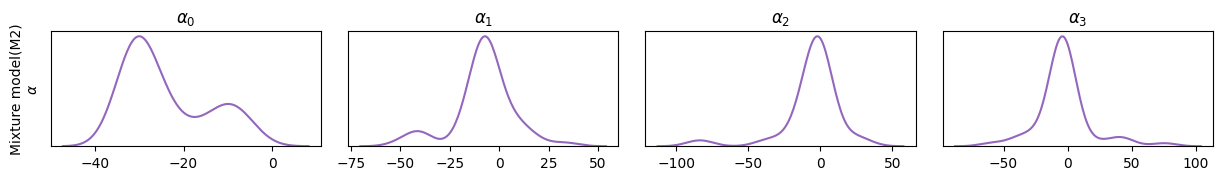

In [84]:
#Plot Alpha

fig, axs = plt.subplots(1,4, figsize=(15,1.5))


#Mixture model rejected Beta
sns.kdeplot(single_model_mixture_estimate['omega'][:,0],  ax=axs[0], color='#9467bd')
sns.kdeplot(single_model_mixture_estimate['omega'][:,1],  ax=axs[1], color='#9467bd')
sns.kdeplot(single_model_mixture_estimate['omega'][:,2],  ax=axs[2], color='#9467bd')
sns.kdeplot(single_model_mixture_estimate['omega'][:,3], ax=axs[3], color='#9467bd')

# Set parameter name

axs[0].set_title(r'$\alpha_0 $')
axs[1].set_title(r'$\alpha_1$')
axs[2].set_title(r'$\alpha_2$')
axs[3].set_title(r'$\alpha_3$')


# Remove the ticklabels for y axis

axs[0].set_yticks([])
axs[1].set_yticks([])
axs[2].set_yticks([])
axs[3].set_yticks([])

for ax in axs.flat:
    ax.label_outer()
# Give labels for models and par
axs[0].set_ylabel(r'Mixture model' +'(M2)' +'\n' +r'$\alpha$')

plt.subplots_adjust(wspace=0.1)

In [15]:
# Plot of the mixture model rejection

omegas = single_model_mixture_estimate['omega']
omegas.shape

# mixture weight assignment
w_exp = jnp.exp(x.T @ omegas.T)
w_1 = w_exp / (1 + w_exp)


In [16]:
w_1_mean = np.mean(w_1, axis=1)
w_2_mean = np.mean(1-w_1, axis=1)

df = pd.DataFrame({'Component 2':w_1_mean[450:500], 'Component 1':w_2_mean[450:500] })

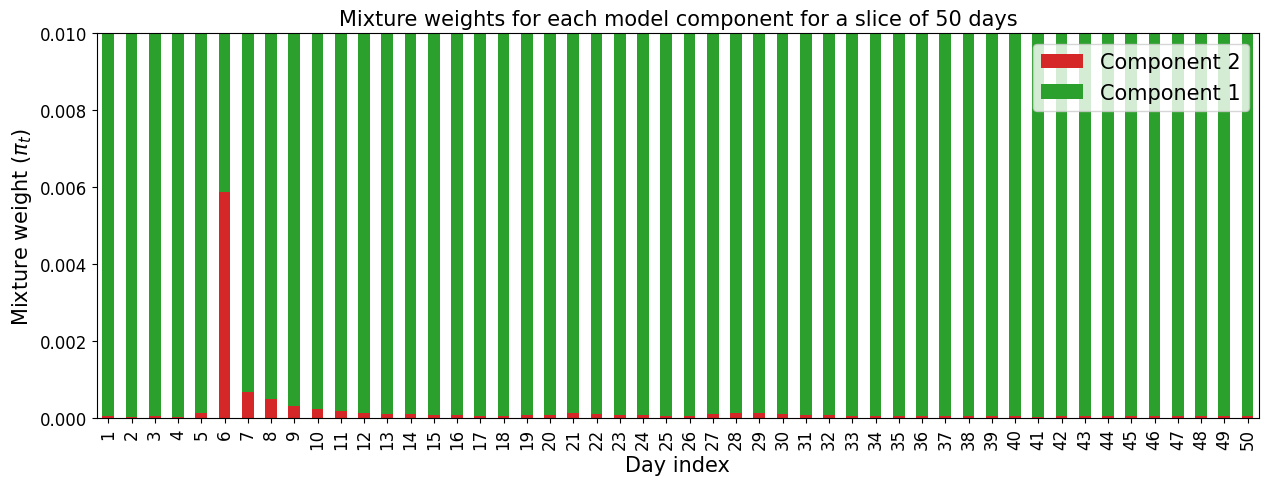

In [65]:

df.plot(kind='bar', stacked=True, figsize=(15,5), color=['#d62728','#2ca02c'])
plt.title('Mixture weights for each model component for a slice of 50 days',fontsize=15)
plt.ylim(0,0.01)
plt.yticks(fontsize=12)
plt.xticks([i for i in range(0,50)], labels=[i for i in range(1,51)],fontsize=12)
plt.xlabel('Day index',fontsize=15)
plt.ylabel(r'Mixture weight ($\pi_t$)',fontsize=15)
plt.legend(loc='upper right',fontsize=15)
plt.show()

## Mixture model generated data

In [17]:
with open('./../results/simulation/mix_sim_bawden_single', 'rb') as fp:
    mixture_model_single_estimate = pickle.load(fp)

with open('./../results/simulation/mix_sim_bawden_mixture', 'rb') as fp:
    mixture_model_mixture_estimate = pickle.load(fp)
    

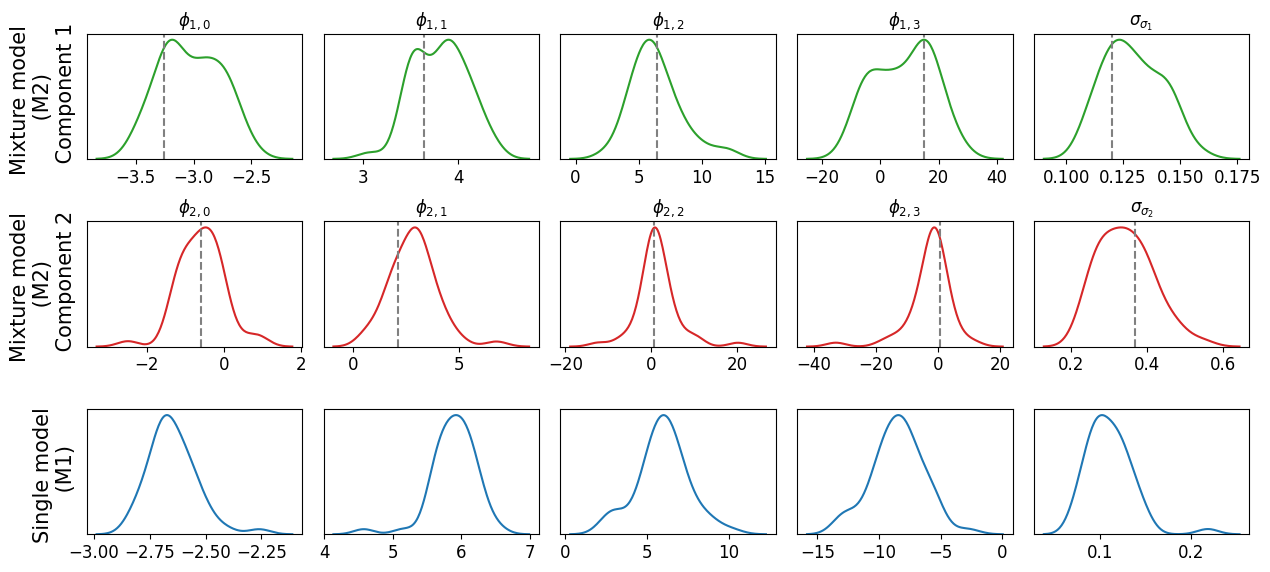

In [35]:
# Plot for  Phi

fig, axs = plt.subplots(3,5, figsize=(15,6.5))
#Single model
sns.kdeplot(mixture_model_single_estimate['phi'][:,0],  ax=axs[2,0])
sns.kdeplot(mixture_model_single_estimate['phi'][:,1],  ax=axs[2,1])
sns.kdeplot(mixture_model_single_estimate['phi'][:,2],  ax=axs[2,2])
sns.kdeplot(mixture_model_single_estimate['phi'][:,3],  ax=axs[2,3])
sns.kdeplot(mixture_model_single_estimate['sig_sig'],  ax=axs[2,4])

#Mixture mdoel component 1
sns.kdeplot(mixture_model_mixture_estimate['phi1'][:,0],  ax=axs[0,0], color='#2ca02c')
sns.kdeplot(mixture_model_mixture_estimate['phi1'][:,1],  ax=axs[0,1], color='#2ca02c')
sns.kdeplot(mixture_model_mixture_estimate['phi1'][:,2],  ax=axs[0,2], color='#2ca02c')
sns.kdeplot(mixture_model_mixture_estimate['phi1'][:,3],  ax=axs[0,3], color='#2ca02c')
sns.kdeplot(mixture_model_mixture_estimate['sig_sig1'],  ax=axs[0,4], color='#2ca02c')

#Mixture model component 2
sns.kdeplot(mixture_model_mixture_estimate['phi2'][:,0],  ax=axs[1,0], color='#d62728')
sns.kdeplot(mixture_model_mixture_estimate['phi2'][:,1],  ax=axs[1,1], color='#d62728')
sns.kdeplot(mixture_model_mixture_estimate['phi2'][:,2],  ax=axs[1,2], color='#d62728')
sns.kdeplot(mixture_model_mixture_estimate['phi2'][:,3],  ax=axs[1,3], color='#d62728')
sns.kdeplot(mixture_model_mixture_estimate['sig_sig2'],  ax=axs[1,4], color='#d62728')

#Setting true fixed values

axs[0,0].set_title(r'$\phi_{1,0}$',fontsize=12)
axs[0,1].set_title(r'$\phi_{1,1}$',fontsize=12)
axs[0,2].set_title(r'$\phi_{1,2}$',fontsize=12)
axs[0,3].set_title(r'$\phi_{1,3}$',fontsize=12)
axs[0,4].set_title(r'$\sigma_{\sigma_1}$',fontsize=12)

axs[1,0].set_title(r'$\phi_{2,0}$',fontsize=12)
axs[1,1].set_title(r'$\phi_{2,1}$',fontsize=12)
axs[1,2].set_title(r'$\phi_{2,2}$',fontsize=12)
axs[1,3].set_title(r'$\phi_{2,3}$',fontsize=12)
axs[1,4].set_title(r'$\sigma_{\sigma_2}$',fontsize=12)

axs[0,0].axvline(x = -3.26, linestyle = "dashed", color='grey')
axs[0,1].axvline(x = 3.64, linestyle = "dashed", color='grey')
axs[0,2].axvline(x = 6.44, linestyle = "dashed", color='grey')
axs[0,3].axvline(x = 15.05, linestyle = "dashed", color='grey')
axs[0,4].axvline(x = 0.12, linestyle = "dashed", color='grey')

axs[1,0].axvline(x = -0.59, linestyle = "dashed", color='grey')
axs[1,1].axvline(x = 2.14, linestyle = "dashed", color='grey')
axs[1,2].axvline(x = 0.71, linestyle = "dashed", color='grey')
axs[1,3].axvline(x = 0.57, linestyle = "dashed", color='grey')
axs[1,4].axvline(x = 0.37, linestyle = "dashed", color='grey')


# Remove the ticklabels for y axis

axs[0,0].set_yticks([])
axs[1,0].set_yticks([])
axs[2,0].set_yticks([])

axs[0,1].set_yticks([])
axs[1,1].set_yticks([])
axs[2,1].set_yticks([])

axs[0,2].set_yticks([])
axs[1,2].set_yticks([])
axs[2,2].set_yticks([])

axs[0,3].set_yticks([])
axs[1,3].set_yticks([])
axs[2,3].set_yticks([])

axs[0,4].set_yticks([])
axs[1,4].set_yticks([])
axs[2,4].set_yticks([])

# Give labels for models
axs[0,0].set_ylabel('Mixture model \n (M2) \n Component 1',fontsize=15)
axs[1,0].set_ylabel('Mixture model \n (M2) \n Component 2',fontsize=15)
axs[2,0].set_ylabel('Single model \n (M1)',fontsize=15)

axs[0,1].set_ylabel('')
axs[1,1].set_ylabel('')
axs[2,1].set_ylabel('')

axs[0,2].set_ylabel('')
axs[1,2].set_ylabel('')
axs[2,2].set_ylabel('')

axs[0,3].set_ylabel('')
axs[1,3].set_ylabel('')
axs[2,3].set_ylabel('')

axs[0,4].set_ylabel('')
axs[1,4].set_ylabel('')
axs[2,4].set_ylabel('')


# for ax in axs.flat:
#     ax.label_outer()

plt.subplots_adjust(wspace=0.1, hspace=0.5)

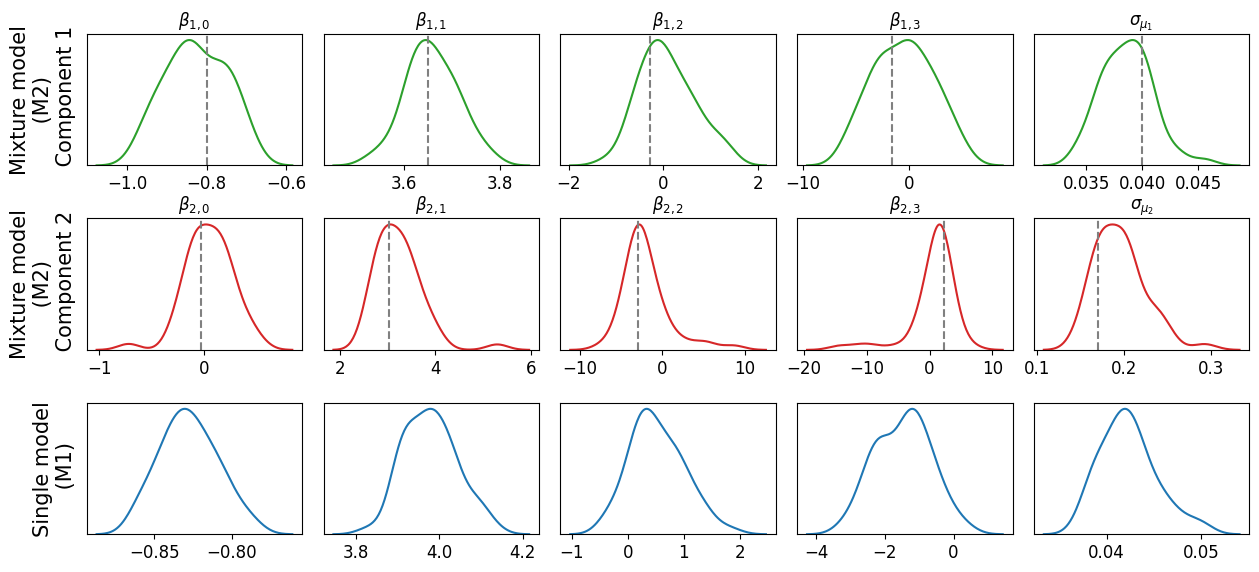

In [70]:
# Plot for  Beta
# beta1 = jnp.array([-0.8,3.65,-0.28, -1.57])
# beta2 = jnp.array([-0.03,3.02,-2.87, 2.24])
fig, axs = plt.subplots(3,5, figsize=(15,6.5))
#Single model
sns.kdeplot(mixture_model_single_estimate['beta'][:,0],  ax=axs[2,0])
sns.kdeplot(mixture_model_single_estimate['beta'][:,1],  ax=axs[2,1])
sns.kdeplot(mixture_model_single_estimate['beta'][:,2],  ax=axs[2,2])
sns.kdeplot(mixture_model_single_estimate['beta'][:,3],  ax=axs[2,3])
sns.kdeplot(mixture_model_single_estimate['sig_mu'],  ax=axs[2,4])

#Mixture mdoel component 1
sns.kdeplot(mixture_model_mixture_estimate['beta1'][:,0],  ax=axs[0,0], color='#2ca02c')
sns.kdeplot(mixture_model_mixture_estimate['beta1'][:,1],  ax=axs[0,1], color='#2ca02c')
sns.kdeplot(mixture_model_mixture_estimate['beta1'][:,2],  ax=axs[0,2], color='#2ca02c')
sns.kdeplot(mixture_model_mixture_estimate['beta1'][:,3],  ax=axs[0,3], color='#2ca02c')
sns.kdeplot(mixture_model_mixture_estimate['sig_mu1'], ax=axs[0,4], color='#2ca02c')

#Mixture model component 2
sns.kdeplot(mixture_model_mixture_estimate['beta2'][:,0], ax=axs[1,0], color='#d62728')
sns.kdeplot(mixture_model_mixture_estimate['beta2'][:,1],  ax=axs[1,1], color='#d62728')
sns.kdeplot(mixture_model_mixture_estimate['beta2'][:,2], ax=axs[1,2], color='#d62728')
sns.kdeplot(mixture_model_mixture_estimate['beta2'][:,3],  ax=axs[1,3], color='#d62728')
sns.kdeplot(mixture_model_mixture_estimate['sig_mu2'],  ax=axs[1,4], color='#d62728')

#Setting true fixed values

axs[0,0].set_title(r'$\beta_{1,0}$',fontsize=12)
axs[0,1].set_title(r'$\beta_{1,1}$',fontsize=12)
axs[0,2].set_title(r'$\beta_{1,2}$',fontsize=12)
axs[0,3].set_title(r'$\beta_{1,3}$',fontsize=12)
axs[0,4].set_title(r'$\sigma_{\mu_1}$',fontsize=12)

axs[1,0].set_title(r'$\beta_{2,0}$',fontsize=12)
axs[1,1].set_title(r'$\beta_{2,1}$',fontsize=12)
axs[1,2].set_title(r'$\beta_{2,2}$',fontsize=12)
axs[1,3].set_title(r'$\beta_{2,3}$',fontsize=12)
axs[1,4].set_title(r'$\sigma_{\mu_2}$',fontsize=12)

axs[0,0].axvline(x = -0.80, linestyle = "dashed", color='grey')
axs[0,1].axvline(x = 3.65, linestyle = "dashed", color='grey')
axs[0,2].axvline(x = -0.28, linestyle = "dashed", color='grey')
axs[0,3].axvline(x = -1.57, linestyle = "dashed", color='grey')
axs[0,4].axvline(x = 0.04, linestyle = "dashed", color='grey')

axs[1,0].axvline(x = -0.03, linestyle = "dashed", color='grey')
axs[1,1].axvline(x = 3.02, linestyle = "dashed", color='grey')
axs[1,2].axvline(x = -2.87, linestyle = "dashed", color='grey')
axs[1,3].axvline(x = 2.24, linestyle = "dashed", color='grey')
axs[1,4].axvline(x = 0.17, linestyle = "dashed", color='grey')

# Remove the ticklabels for y axis

axs[0,0].set_yticks([])
axs[1,0].set_yticks([])
axs[2,0].set_yticks([])

axs[0,1].set_yticks([])
axs[1,1].set_yticks([])
axs[2,1].set_yticks([])

axs[0,2].set_yticks([])
axs[1,2].set_yticks([])
axs[2,2].set_yticks([])

axs[0,3].set_yticks([])
axs[1,3].set_yticks([])
axs[2,3].set_yticks([])

axs[0,4].set_yticks([])
axs[1,4].set_yticks([])
axs[2,4].set_yticks([])

# Give labels for models
axs[0,0].set_ylabel('Mixture model\n (M2) \n Component 1',fontsize=15)
axs[1,0].set_ylabel('Mixture model\n (M2) \n Component 2',fontsize=15)
axs[2,0].set_ylabel('Single model\n (M1)',fontsize=15)

axs[0,1].set_ylabel('')
axs[1,1].set_ylabel('')
axs[2,1].set_ylabel('')

axs[0,2].set_ylabel('')
axs[1,2].set_ylabel('')
axs[2,2].set_ylabel('')

axs[0,3].set_ylabel('')
axs[1,3].set_ylabel('')
axs[2,3].set_ylabel('')

axs[0,4].set_ylabel('')
axs[1,4].set_ylabel('')
axs[2,4].set_ylabel('')
# for ax in axs.flat:
#     ax.label_outer()

plt.subplots_adjust(wspace=0.1, hspace=0.4)

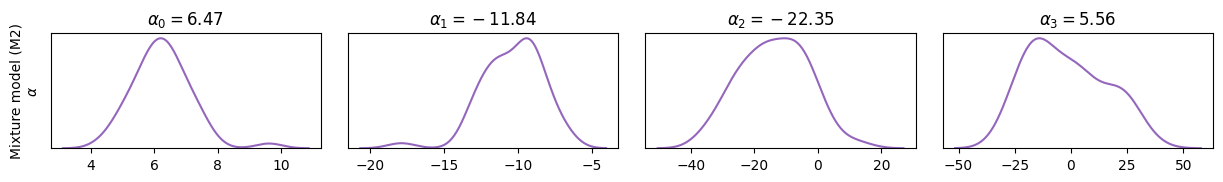

In [92]:
#Plot Alpha
# omega = jnp.array([6.47,-11.84,-22.35, 5.56])
fig, axs = plt.subplots(1,4, figsize=(15,1.5))


#Mixture model rejected Beta
sns.kdeplot(mixture_model_mixture_estimate['omega'][:,0],  ax=axs[0], color='#9467bd')
sns.kdeplot(mixture_model_mixture_estimate['omega'][:,1],  ax=axs[1], color='#9467bd')
sns.kdeplot(mixture_model_mixture_estimate['omega'][:,2],  ax=axs[2], color='#9467bd')
sns.kdeplot(mixture_model_mixture_estimate['omega'][:,3],  ax=axs[3], color='#9467bd')

# Set parameter name

axs[0].set_title(r'$\alpha_0 = 6.47$')
axs[1].set_title(r'$\alpha_1 = -11.84$')
axs[2].set_title(r'$\alpha_2 = -22.35$')
axs[3].set_title(r'$\alpha_3 = 5.56$')


# Remove the ticklabels for y axis

axs[0].set_yticks([])
axs[1].set_yticks([])
axs[2].set_yticks([])
axs[3].set_yticks([])


# Give labels for models and par
axs[0].set_ylabel(r'Mixture model (M2)' +'\n' +r'$\alpha$')
axs[1].set_ylabel('')
axs[2].set_ylabel('')
axs[3].set_ylabel('')

plt.subplots_adjust(wspace=0.1, hspace=0.3)

In [38]:
# Plot of the mixture model switch

omegas = mixture_model_mixture_estimate['omega']
omegas.shape

# #mixture weight assignment
w_exp = jnp.exp(x.T @ omegas.T)
w_1 = w_exp / (1 + w_exp)
# gate = numpyro.deterministic('gate',jnp.stack((w_1, 1- w_1), axis = -1))

w_1_mean = np.mean(w_1, axis=1)
w_2_mean = np.mean(1-w_1, axis=1)

df = pd.DataFrame({'Component 1':w_1_mean[450:500], 'Component 2':w_2_mean[450:500]})

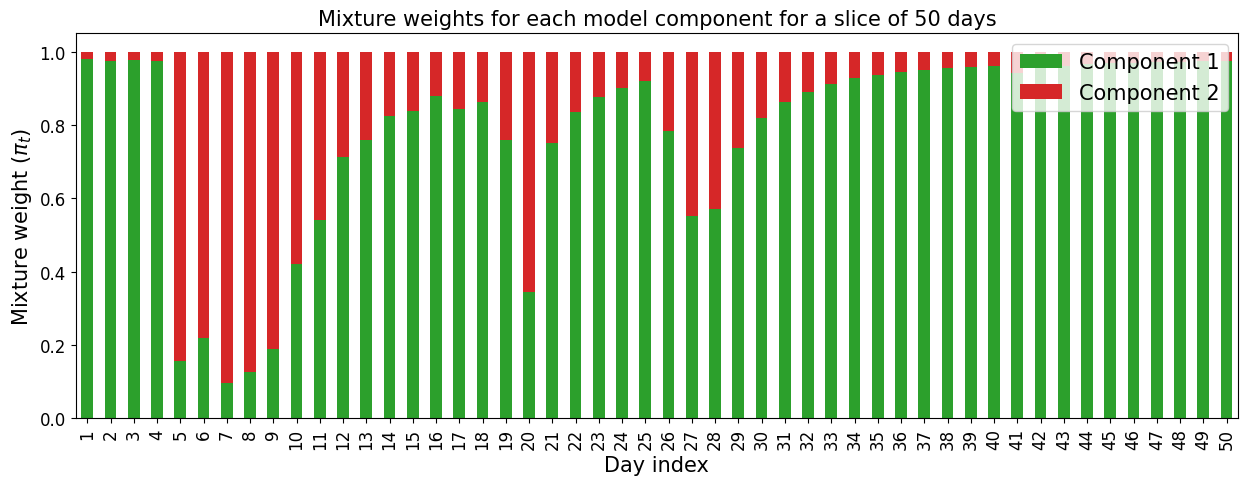

In [74]:
df.plot(kind='bar', stacked=True, figsize=(15,5), color=['#2ca02c','#d62728'])
plt.title('Mixture weights for each model component for a slice of 50 days',fontsize=15)
plt.yticks(fontsize=12)
plt.xticks([i for i in range(0,50)], labels=[i for i in range(1,51)],fontsize=12)
plt.xlabel('Day index',fontsize=15)
plt.ylabel(r'Mixture weight ($\pi_t$)',fontsize=15)
plt.legend(loc='upper right', fontsize=15)
plt.show()

# Prediction plot

In [18]:
import scipy.stats as st

In [21]:
# Predictions from the single model

def pred_single(param_dict,x, rng):
    n = x.shape[1]
    
    beta = param_dict['beta']
    phi = param_dict['phi']
    sig_mu = param_dict['sig_mu']
    sig_sig = param_dict['sig_sig']

    s = beta.shape[0]

    mu = np.exp(x.T @ beta.T) + st.norm(0,sig_mu).rvs(size=(n,s), random_state = rng)
    std = np.exp(x.T @ phi.T) + st.norm(0,sig_sig).rvs(size=(n,s), random_state = rng)

    preds = st.gamma(mu**2/std**2,scale=std**2/mu).rvs(random_state = rng)

    return preds


def pred_mixture(param_dict,x, rng):
    n = x.shape[1]
    
    beta1 = param_dict['beta1']
    phi1 = param_dict['phi1']
    sig_mu1 = param_dict['sig_mu1']
    sig_sig1 = param_dict['sig_sig1']

    beta2 = param_dict['beta2']
    phi2 = param_dict['phi2']
    sig_mu2 = param_dict['sig_mu2']
    sig_sig2 = param_dict['sig_sig2']
    omega = param_dict['omega']

    s = beta1.shape[0]

    mu1 = np.exp(x.T @ beta1.T + st.norm(0,sig_mu1).rvs(size=(n,s), random_state = rng))
    std1 = np.exp(x.T @ phi1.T + st.norm(0,sig_sig1).rvs(size=(n,s), random_state = rng))

    mu2 = np.exp(x.T @ beta2.T + st.norm(0,sig_mu2).rvs(size=(n,s), random_state = rng))
    std2 = np.exp(x.T @ phi2.T + st.norm(0,sig_sig2).rvs(size=(n,s), random_state = rng))

    w_exp = jnp.exp(x.T @ omega.T)
    w_1 = w_exp / (1 + w_exp)
    
    
    #w_1_mean = np.mean(w_1, axis=1)
    
    selection = st.bernoulli(w_1).rvs(random_state = rng)
    
    pred1 = st.gamma(mu1**2/std1**2,scale=std1**2/mu1).rvs(random_state = rng)
    pred2 = st.gamma(mu2**2/std2**2,scale=std2**2/mu2).rvs(random_state = rng)

    pred = pred1 * selection + pred2 * (1-selection)
    
    
    return pred

def pred_mixture_weights(param_dict,x, rng):
    n = x.shape[1]
    
    beta1 = param_dict['beta1']
    phi1 = param_dict['phi1']
    sig_mu1 = param_dict['sig_mu1']
    sig_sig1 = param_dict['sig_sig1']

    beta2 = param_dict['beta2']
    phi2 = param_dict['phi2']
    sig_mu2 = param_dict['sig_mu2']
    sig_sig2 = param_dict['sig_sig2']
    omega = param_dict['omega']

    s = beta1.shape[0]

    mu1 = np.exp(x.T @ beta1.T + st.norm(0,sig_mu1).rvs(size=(n,s), random_state = rng))
    std1 = np.exp(x.T @ phi1.T + st.norm(0,sig_sig1).rvs(size=(n,s), random_state = rng))

    mu2 = np.exp(x.T @ beta2.T + st.norm(0,sig_mu2).rvs(size=(n,s), random_state = rng))
    std2 = np.exp(x.T @ phi2.T + st.norm(0,sig_sig2).rvs(size=(n,s), random_state = rng))

    w_exp = jnp.exp(x.T @ omega.T)
    w_1 = w_exp / (1 + w_exp)
    
    
    return w_1

In [20]:
m1_pred_single = pred_single(single_model_single_estimate,x,4)

In [21]:
m2_pred_single = pred_mixture(single_model_mixture_estimate,x,4)
m2_pred_single_weights = pred_mixture_weights(single_model_mixture_estimate,x,4)

In [23]:
m1_pred_mixture = pred_single(mixture_model_single_estimate,x,2)
m2_pred_mixture = pred_mixture(mixture_model_mixture_estimate,x,2)
m2_pred_mixture_weights = pred_mixture_weights(mixture_model_mixture_estimate,x,2)

## Plots for a single realization

In [24]:
switch_mix1 = jnp.where(m2_pred_mixture_weights[:,0]< 0.5,-1,jnp.nan)
switch_mix2 = jnp.where(m2_pred_mixture_weights[:,0]>= 0.5,-1,jnp.nan)
switch_single1 = jnp.where(m2_pred_single_weights[:,0]< 0.5,-1,jnp.nan)
switch_single2 = jnp.where(m2_pred_single_weights[:,0]>= 0.5,-1,jnp.nan)


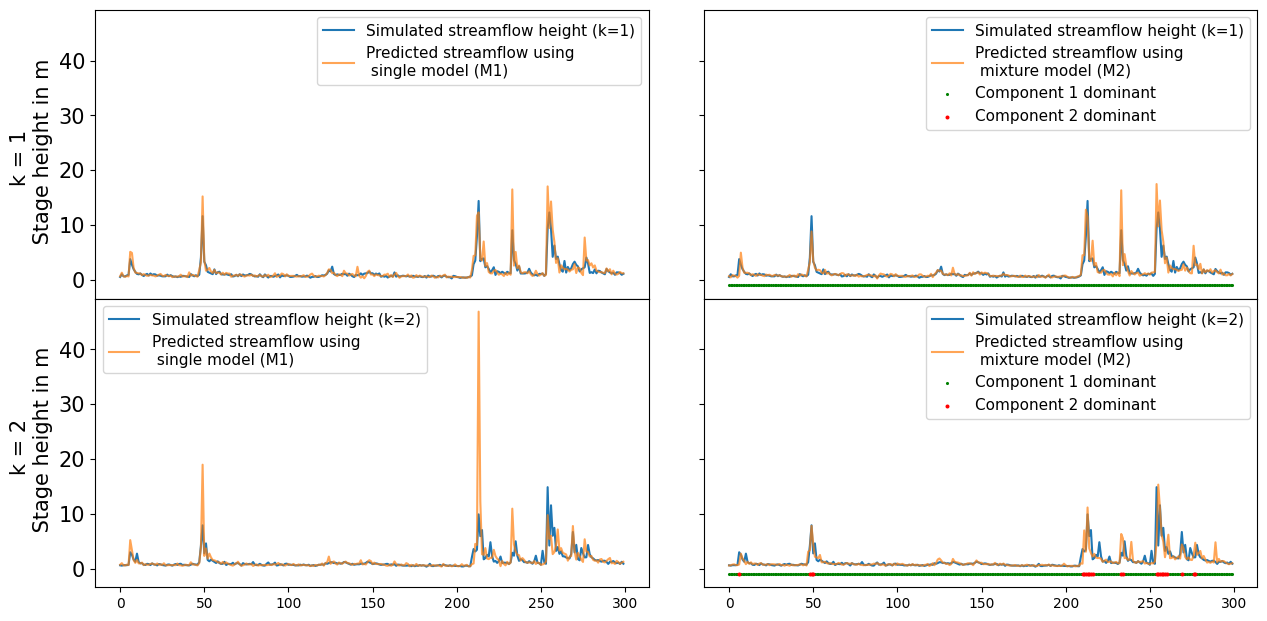

In [30]:
fig, axs = plt.subplots(2,2, figsize=(15,7.5), sharex=True, sharey=True)
plt.rcParams['ytick.labelsize'] = 15
axs[0,0].plot(h_sim[3,200:500], label = 'Simulated streamflow height (k=1)')
axs[0,0].plot(m1_pred_single[200:500,2], alpha=0.7, label = 'Predicted streamflow using \n single model (M1)')
axs[0,0].legend(fontsize=11)

axs[0,1].plot(h_sim[3,200:500], label = 'Simulated streamflow height (k=1)')
axs[0,1].plot(m2_pred_single[200:500,2], alpha=0.7, label = 'Predicted streamflow using \n mixture model (M2)')
axs[0,1].scatter([x for x in range(300)],switch_single1[200:500], s=1.5,label = 'Component 1 dominant', c='green')
axs[0,1].scatter([x for x in range(300)],switch_single2[200:500], s=3.5,label = 'Component 2 dominant', c='red')
axs[0,1].legend(fontsize=11)

axs[1,0].plot(h_sim_mix[1,200:500], label = 'Simulated streamflow height (k=2)')
axs[1,0].plot(m1_pred_mixture[200:500,0], alpha=0.7, label = 'Predicted streamflow using \n single model (M1)')
axs[1,0].legend(fontsize=11)

axs[1,1].plot(h_sim_mix[1,200:500], label = 'Simulated streamflow height (k=2)')
axs[1,1].plot(m2_pred_mixture[200:500,0], alpha=0.7, label = 'Predicted streamflow using \n mixture model (M2)')
axs[1,1].scatter([x for x in range(300)],switch_mix2[200:500], s=1.5,label = 'Component 1 dominant', c='green')
axs[1,1].scatter([x for x in range(300)],switch_mix1[200:500], s=3.5,label = 'Component 2 dominant', c='red')
axs[1,1].legend(fontsize=11)


# Give labels for models
axs[0,0].set_ylabel('k = 1 \n Stage height in m', fontsize=15)
axs[1,0].set_ylabel('k = 2 \n Stage height in m', fontsize=15)

plt.subplots_adjust(wspace=0.1, hspace=0)